In [1]:
import numpy as np
import matplotlib.pyplot as plt

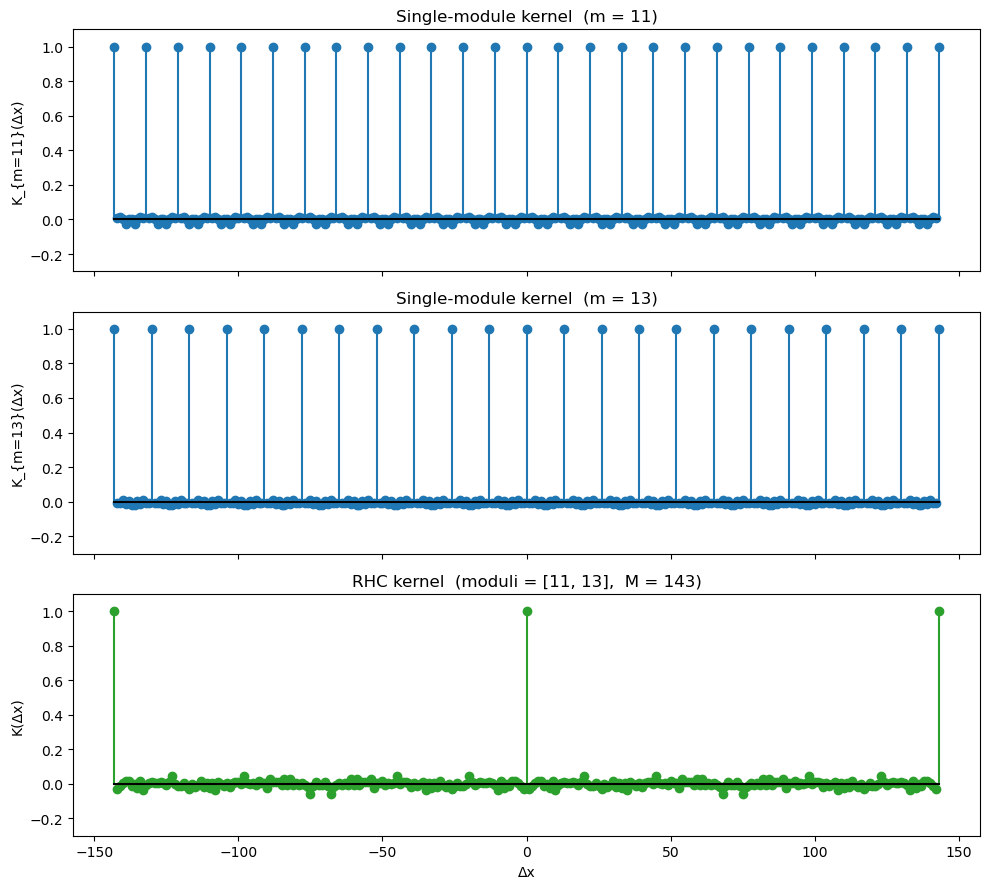


Moduli: [11, 13]
Effective range M = 143
Vector dimension D = 2000
K(0) = 1.0000   (should be ≈1)
K(1) = -0.0277   (should be ≈0)
K(M) = 1.0000   (should be ≈1, periodicity)


In [5]:
"""
Residue Hyperdimensional Computing — Similarity Kernel Demo
============================================================
Implements the RHC encoding from Kymn et al. (2025):
  z(x) = ⊙_k  z_{m_k}(x)
where each z_{m_k} is an FPE with phases drawn from the m_k-th roots of unity.
"""

# ---- Parameters ----
D = 2000            # vector dimension
moduli = [11, 13]   # pairwise co-prime moduli (change to e.g. [3,5,7])
M = np.prod(moduli) # effective range

# ---- Build base vectors for each modulus ----
# For modulus m, each phase φ_d is drawn uniformly from the m-th roots of unity:
#   φ_d = 2π k / m,  k ~ Uniform{0, 1, ..., m-1}
base_vectors = {}
for m in moduli:
    k = np.random.randint(0, m, size=D)       # random root index per dimension
    phi = 2 * np.pi * k / m                    # phases
    base_vectors[m] = np.exp(1j * phi)          # phasor base vector z_m

# ---- Encode integer x as RHC vector ----
def encode(x):
    """z(x) = ⊙_k z_{m_k}^x  (component-wise)"""
    vec = np.ones(D, dtype=complex)
    for m in moduli:
        vec *= base_vectors[m] ** x             # z_m(x) = z_m^x
    return vec

# ---- Kernel: normalised real inner product ----
def kernel(x1, x2):
    z1 = encode(x1)
    z2 = encode(x2)
    return np.real(np.dot(z1.conj(), z2)) / D

# ---- Evaluate kernel K(Δx) for a range of offsets ----
x_ref = 0
offsets = np.arange(-M, M + 1)
K_vals = np.array([kernel(x_ref, x_ref + dx) for dx in offsets])

# ---- Also compute per-module kernels for comparison ----
def single_module_kernel(m, dx_array):
    """Kernel from just one FPE module."""
    z_base = base_vectors[m]
    vals = []
    for dx in dx_array:
        z_dx = z_base ** dx
        vals.append(np.real(np.sum(z_dx)) / D)
    return np.array(vals)

# ---- Plot ----
fig, axes = plt.subplots(1 + len(moduli), 1, figsize=(10, 3 * (1 + len(moduli))),
                         sharex=True)

# Per-module kernels
for i, m in enumerate(moduli):
    K_mod = single_module_kernel(m, offsets)
    axes[i].stem(offsets, K_mod, linefmt='C0-', markerfmt='C0o', basefmt='k-')
    axes[i].set_ylabel(f'K_{{m={m}}}(Δx)')
    axes[i].set_title(f'Single-module kernel  (m = {m})')
    axes[i].set_ylim(-0.3, 1.1)

# Combined RHC kernel
axes[-1].stem(offsets, K_vals, linefmt='C2-', markerfmt='C2o', basefmt='k-')
axes[-1].set_ylabel('K(Δx)')
axes[-1].set_xlabel('Δx')
axes[-1].set_title(f'RHC kernel  (moduli = {moduli},  M = {M})')
axes[-1].set_ylim(-0.3, 1.1)

plt.tight_layout()
plt.savefig('rhc_kernel.png', dpi=150)
plt.show()

print(f"\nModuli: {moduli}")
print(f"Effective range M = {M}")
print(f"Vector dimension D = {D}")
print(f"K(0) = {kernel(0,0):.4f}   (should be ≈1)")
print(f"K(1) = {kernel(0,1):.4f}   (should be ≈0)")
print(f"K(M) = {kernel(0,M):.4f}   (should be ≈1, periodicity)")

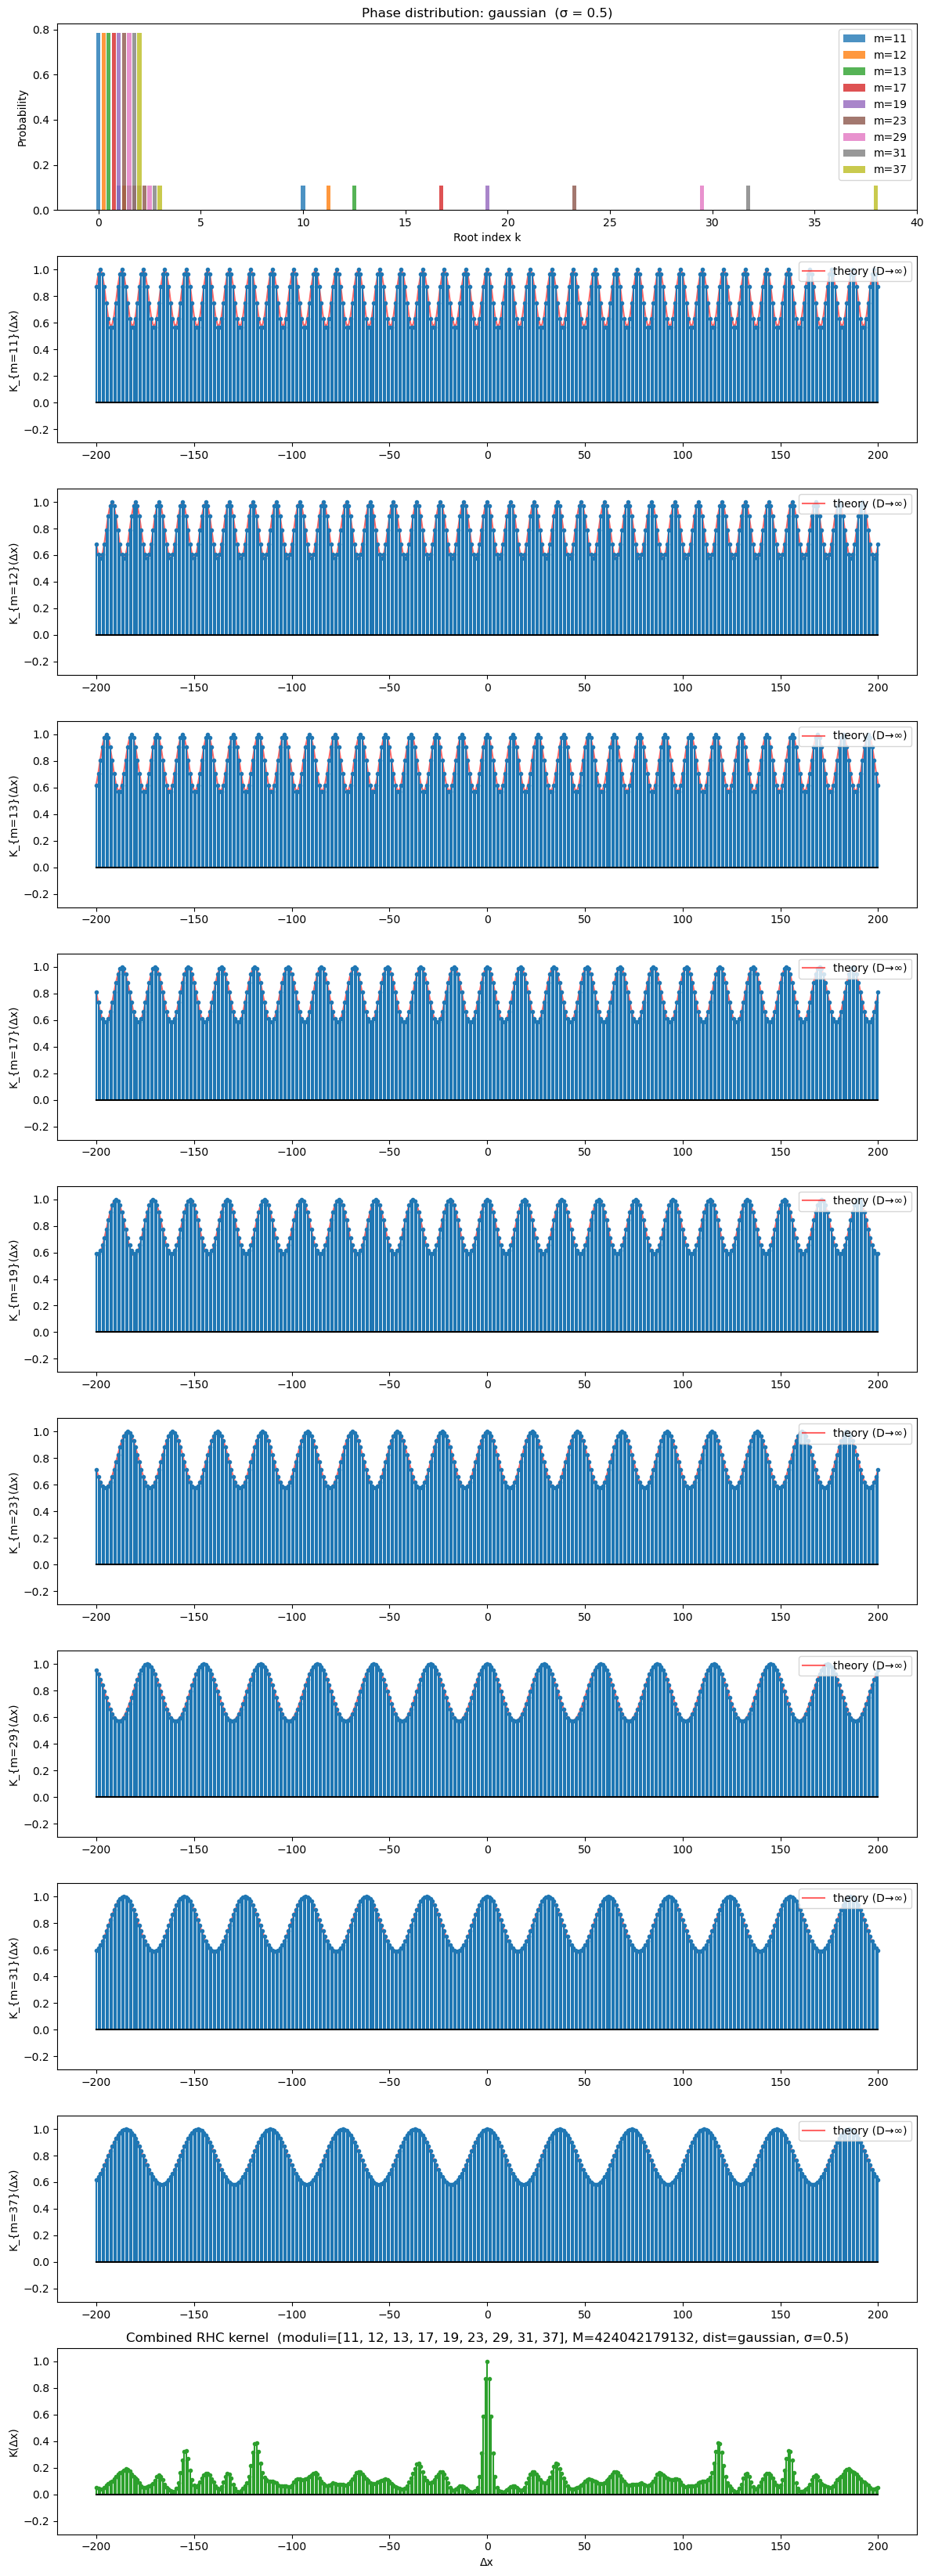


Distribution: gaussian,  σ = 0.5
Moduli: [11, 12, 13, 17, 19, 23, 29, 31, 37],  M = 424042179132,  D = 4000
K(Δx=0)  = 1.0000
K(Δx=1 ) = 0.8726
K(Δx=2 ) = 0.5850
K(Δx=3 ) = 0.3080
K(Δx=5 ) = 0.0532
K(Δx=10) = 0.0317
K(Δx=M)  = 1.0000


In [58]:
"""
RHC Kernel Explorer — Phase Distribution Determines Kernel Shape
=================================================================
Each module samples phases from the m-th roots of unity, but the
*probability weights* over those roots determine the kernel shape
(Bochner's theorem applied to the discrete case).

Available distributions (all periodic with period m):
  'uniform'    — equal weight on all roots  → sinc-comb (impulse at multiples of m)
  'gaussian'   — discrete Gaussian weights → periodic Gaussian-like kernel
  'laplace'    — discrete Laplace weights  → periodic exponential-decay kernel
  'triangular' — discrete triangular wts   → periodic triangular kernel
  'raised_cos' — raised-cosine weights     → periodic smooth bell kernel

The `sigma` parameter controls the width for all non-uniform distributions.
Larger sigma → narrower kernel (less similarity between nearby integers).
Smaller sigma → wider kernel (more graded similarity).
"""

import numpy as np
import matplotlib.pyplot as plt

# ===================== CONFIGURATION =====================
D = 4000                    # vector dimension
moduli = [11, 12, 13, 17, 19, 23, 29, 31, 37]       # your RNS moduli
distribution = 'gaussian'   # <<< CHANGE THIS
sigma = 0.5         # width param (in units of root-index)
# =========================================================

M = int(np.prod(moduli))

def make_weights(m, dist, sigma):
    """
    Return probability weights over the m-th roots of unity.
    Root k has phase 2πk/m, for k = 0, 1, ..., m-1.
    We define distances on the cyclic group Z/mZ.
    """
    k = np.arange(m)
    # circular distance from 0
    dist_k = np.minimum(k, m - k).astype(float)

    if dist == 'uniform':
        w = np.ones(m)

    elif dist == 'gaussian':
        w = np.exp(-0.5 * (dist_k / sigma) ** 2)

    elif dist == 'laplace':
        w = np.exp(-dist_k / sigma)

    elif dist == 'triangular':
        w = np.maximum(0, 1 - dist_k / (sigma * 3))

    elif dist == 'raised_cos':
        # raised cosine window: cos²(π d / (2 * width)), zero outside width
        width = sigma * 3
        w = np.where(dist_k <= width,
                     np.cos(np.pi * dist_k / (2 * width)) ** 2,
                     0.0)
    else:
        raise ValueError(f"Unknown distribution: {dist}")

    w /= w.sum()  # normalise to probability
    return w


def build_base_vector(m, dist, sigma, D):
    """Sample D phases from the m-th roots of unity with given weights."""
    weights = make_weights(m, dist, sigma)
    k = np.random.choice(m, size=D, p=weights)
    phi = 2 * np.pi * k / m
    return np.exp(1j * phi), weights


# ---- Build base vectors ----
base_vectors = {}
weight_dicts = {}
for m in moduli:
    bv, w = build_base_vector(m, distribution, sigma, D)
    base_vectors[m] = bv
    weight_dicts[m] = w


# ---- Encode & kernel ----
def encode(x):
    vec = np.ones(D, dtype=complex)
    for m in moduli:
        vec *= base_vectors[m] ** x
    return vec

def kernel(x1, x2):
    z1, z2 = encode(x1), encode(x2)
    return np.real(np.dot(z1.conj(), z2)) / D

def single_module_kernel(m, dx_array):
    z_base = base_vectors[m]
    return np.array([np.real(np.sum(z_base ** dx)) / D for dx in dx_array])


# ---- Evaluate ----
x_ref = 0
max_offset = min(M, 200)  # zoom in to see kernel shape
offsets = np.arange(-max_offset, max_offset + 1)
K_vals = np.array([kernel(x_ref, x_ref + dx) for dx in offsets])


# ---- Theoretical per-module kernel (DFT of the weights) ----
def theoretical_module_kernel(m, dist, sigma, dx_array):
    """K_m(Δx) = Σ_k w_k · exp(i 2πk Δx / m)  (real part)"""
    weights = make_weights(m, dist, sigma)
    k = np.arange(m)
    K = []
    for dx in dx_array:
        K.append(np.real(np.sum(weights * np.exp(1j * 2 * np.pi * k * dx / m))))
    return np.array(K)


# ---- Plot ----
n_panels = len(moduli) + 2  # weight panels + per-module + combined
fig, axes = plt.subplots(n_panels, 1, figsize=(12, 3 * n_panels))

# Panel 0: show the weight distributions
ax = axes[0]
for i, m in enumerate(moduli):
    w = weight_dicts[m]
    k = np.arange(m)
    ax.bar(k + i * 0.25, w, width=0.2, alpha=0.8, label=f'm={m}')
ax.set_xlabel('Root index k')
ax.set_ylabel('Probability')
ax.set_title(f'Phase distribution: {distribution}  (σ = {sigma})')
ax.legend()

# Per-module kernels
for i, m in enumerate(moduli):
    ax = axes[1 + i]
    K_mod = single_module_kernel(m, offsets)
    K_theory = theoretical_module_kernel(m, distribution, sigma, offsets)
    ax.plot(offsets, K_theory, 'r-', lw=1.5, alpha=0.6, label='theory (D→∞)')
    ax.stem(offsets, K_mod, linefmt='C0-', markerfmt='C0.', basefmt='k-')
    ax.set_ylabel(f'K_{{m={m}}}(Δx)')
    ax.set_ylim(-0.3, 1.1)
    ax.legend(loc='upper right')

# Combined RHC kernel
ax = axes[-1]
ax.stem(offsets, K_vals, linefmt='C2-', markerfmt='C2.', basefmt='k-')
ax.set_ylabel('K(Δx)')
ax.set_xlabel('Δx')
ax.set_title(f'Combined RHC kernel  (moduli={moduli}, M={M}, dist={distribution}, σ={sigma})')
ax.set_ylim(-0.3, 1.1)

plt.tight_layout()
plt.savefig('rhc_kernel_shaped.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Print summary ----
print(f"\n{'='*60}")
print(f"Distribution: {distribution},  σ = {sigma}")
print(f"Moduli: {moduli},  M = {M},  D = {D}")
print(f"{'='*60}")
print(f"K(Δx=0)  = {kernel(0,0):.4f}")
for dx in [1, 2, 3, 5, 10]:
    print(f"K(Δx={dx:<2}) = {kernel(0,dx):.4f}")
print(f"K(Δx=M)  = {kernel(0,M):.4f}")

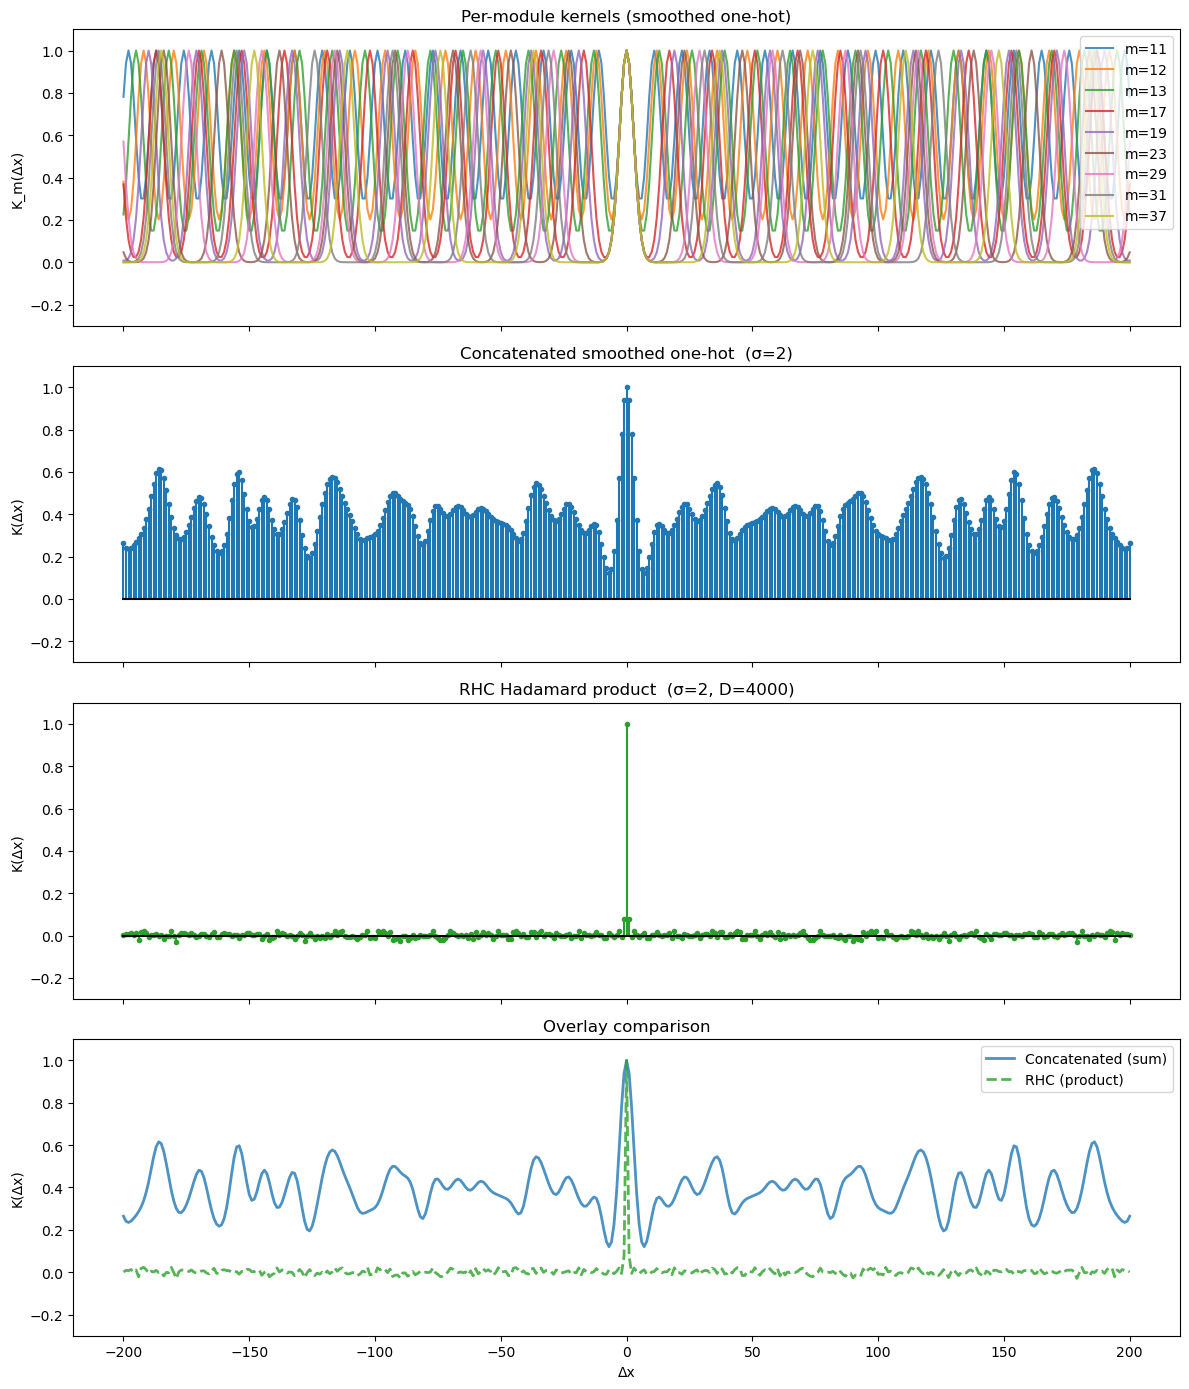


σ = 2, moduli = [11, 12, 13, 17, 19, 23, 29, 31, 37]
  Δx      Concat         RHC
------------------------------
   0      1.0000      1.0000
   1      0.9395      0.0776
   2      0.7792     -0.0059
   3      0.5715      0.0198
   5      0.2259     -0.0070
  10      0.2616      0.0008
  11      0.3162      0.0031
  12      0.3485      0.0173
  13      0.3551      0.0027
  20      0.3775     -0.0019
  30      0.3905      0.0027


In [32]:
"""
Concatenated Smoothed One-Hot vs RHC (Hadamard FPE)
====================================================
Shows that the similarity kernels have the same structure:
- Concatenation → sum of per-module kernels (normalized)
- Hadamard FPE  → product of per-module kernels

Both are governed by the same periodic bumps.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---- Config ----
moduli = [11, 12, 13, 17, 19, 23, 29, 31, 37]
sigma = 2          # smoothing width for the one-hot Gaussian

max_offset = 200
offsets = np.arange(-max_offset, max_offset + 1)

# ============================================================
# Method 1: Concatenated smoothed one-hot
# ============================================================
# For modulus m, encode x as a length-m vector where entry k
# gets weight ∝ exp(-circular_dist(x mod m, k)^2 / 2σ²)

def smooth_onehot(x, m, sigma):
    k = np.arange(m)
    residue = x % m
    dist_k = np.minimum(np.abs(k - residue), m - np.abs(k - residue)).astype(float)
    v = np.exp(-0.5 * (dist_k / sigma) ** 2)
    v /= np.linalg.norm(v)
    return v

def encode_concat(x):
    return np.concatenate([smooth_onehot(x, m, sigma) for m in moduli])

K0_concat = None  # will cache normalization

def kernel_concat(x1, x2):
    global K0_concat
    z1 = encode_concat(x1)
    z2 = encode_concat(x2)
    raw = np.dot(z1, z2)
    if K0_concat is None:
        K0_concat = np.dot(encode_concat(0), encode_concat(0))
    return raw / K0_concat

# ============================================================
# Method 2: RHC with Gaussian-weighted roots of unity
# ============================================================
D = 4000

def make_weights(m, sigma):
    k = np.arange(m)
    dist_k = np.minimum(k, m - k).astype(float)
    w = np.exp(-0.5 * (dist_k / sigma) ** 2)
    w /= w.sum()
    return w

base_vectors = {}
for m in moduli:
    weights = make_weights(m, sigma)
    k = np.random.choice(m, size=D, p=weights)
    phi = 2 * np.pi * k / m
    base_vectors[m] = np.exp(1j * phi)

def encode_rhc(x):
    vec = np.ones(D, dtype=complex)
    for m in moduli:
        vec *= base_vectors[m] ** x
    return vec

def kernel_rhc(x1, x2):
    z1 = encode_rhc(x1)
    z2 = encode_rhc(x2)
    return np.real(np.dot(z1.conj(), z2)) / D

# ============================================================
# Evaluate
# ============================================================
K_concat = np.array([kernel_concat(0, dx) for dx in offsets])
K_rhc    = np.array([kernel_rhc(0, dx) for dx in offsets])

# Per-module kernels (analytic, from the smoothed one-hot)
def per_module_kernel(m, sigma, dx_array):
    """K_m(Δx) for the smoothed one-hot: inner product of two shifted Gaussians on Z/mZ."""
    v0 = smooth_onehot(0, m, sigma)
    return np.array([np.dot(v0, smooth_onehot(dx, m, sigma)) for dx in dx_array])

K_per_mod = {m: per_module_kernel(m, sigma, offsets) for m in moduli}

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

# Per-module kernels
ax = axes[0]
for m in moduli:
    ax.plot(offsets, K_per_mod[m], label=f'm={m}', alpha=0.8)
ax.set_ylabel('K_m(Δx)')
ax.set_title('Per-module kernels (smoothed one-hot)')
ax.legend()
ax.set_ylim(-0.3, 1.1)

# Concatenated
ax = axes[1]
ax.stem(offsets, K_concat, linefmt='C0-', markerfmt='C0.', basefmt='k-')
ax.set_ylabel('K(Δx)')
ax.set_title(f'Concatenated smoothed one-hot  (σ={sigma})')
ax.set_ylim(-0.3, 1.1)

# RHC
ax = axes[2]
ax.stem(offsets, K_rhc, linefmt='C2-', markerfmt='C2.', basefmt='k-')
ax.set_ylabel('K(Δx)')
ax.set_title(f'RHC Hadamard product  (σ={sigma}, D={D})')
ax.set_ylim(-0.3, 1.1)

# Overlay
ax = axes[3]
ax.plot(offsets, K_concat, 'C0-', lw=2, alpha=0.8, label='Concatenated (sum)')
ax.plot(offsets, K_rhc, 'C2--', lw=2, alpha=0.8, label='RHC (product)')
ax.set_ylabel('K(Δx)')
ax.set_xlabel('Δx')
ax.set_title('Overlay comparison')
ax.legend()
ax.set_ylim(-0.3, 1.1)

plt.tight_layout()
plt.savefig('concat_vs_rhc.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Print ----
print(f"\n{'='*60}")
print(f"σ = {sigma}, moduli = {moduli}")
print(f"{'='*60}")
print(f"{'Δx':>4}  {'Concat':>10}  {'RHC':>10}")
print(f"{'-'*30}")
for dx in [0, 1, 2, 3, 5, 10, 11, 12, 13, 20, 30]:
    print(f"{dx:>4}  {kernel_concat(0, dx):>10.4f}  {kernel_rhc(0, dx):>10.4f}")

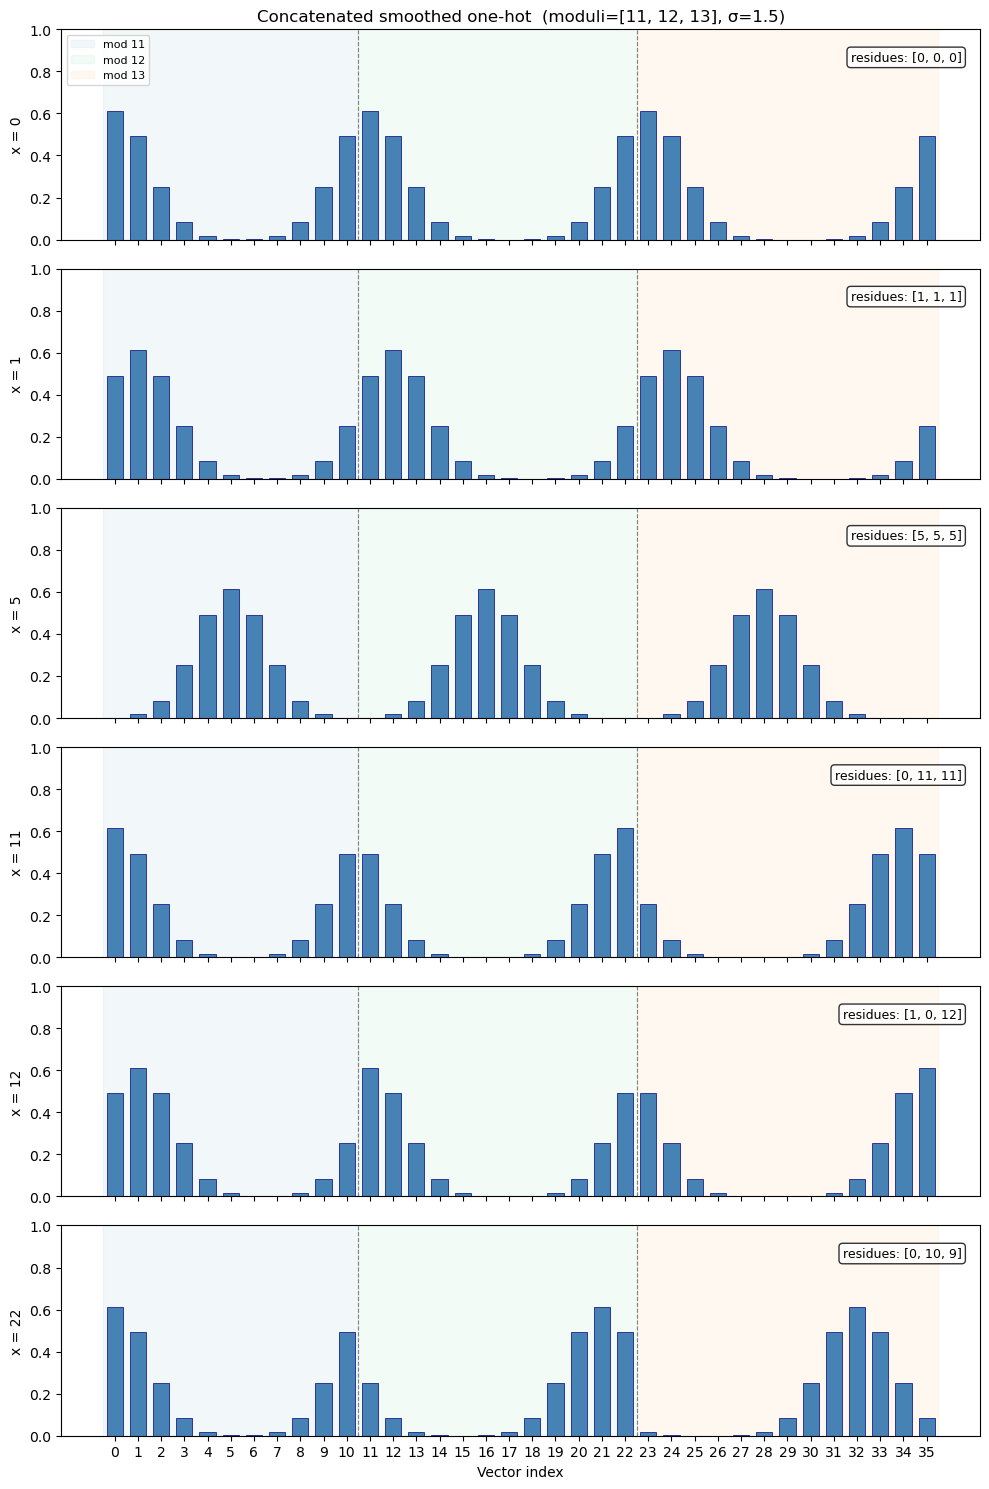

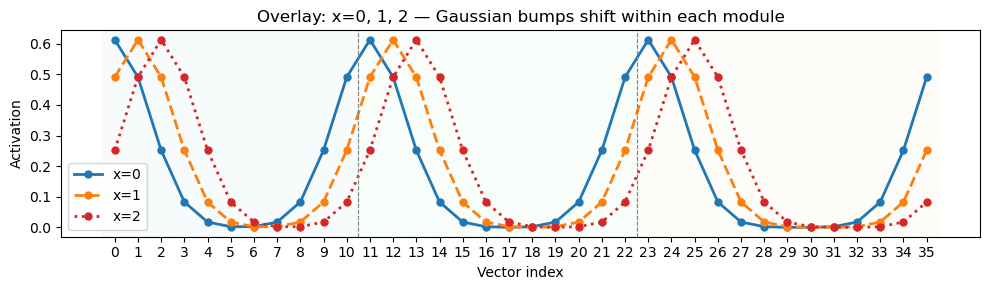

Total vector dimension: 36
x=  0  residues=[0, 0, 0]
x=  1  residues=[1, 1, 1]
x=  5  residues=[5, 5, 5]
x= 11  residues=[0, 11, 11]
x= 12  residues=[1, 0, 12]
x= 22  residues=[0, 10, 9]


In [ ]:
"""
Visualize concatenated smoothed one-hot vectors for a few values of x.
Shows the per-module segments side by side.
"""

import numpy as np
import matplotlib.pyplot as plt

moduli = [11, 12, 13]
sigma = 1.5
total_dim = sum(moduli)

def smooth_onehot(x, m, sigma):
    k = np.arange(m)
    residue = x % m
    dist_k = np.minimum(np.abs(k - residue), m - np.abs(k - residue)).astype(float)
    v = np.exp(-0.5 * (dist_k / sigma) ** 2)
    v /= np.linalg.norm(v)
    return v

def encode_concat(x):
    return np.concatenate([smooth_onehot(x, m, sigma) for m in moduli])

# Example values
examples = [0, 1, 5, 11, 12, 22]

fig, axes = plt.subplots(len(examples), 1, figsize=(10, 2.5 * len(examples)),
                         sharex=True, sharey=True)

# Module boundaries for shading
boundaries = np.cumsum([0] + moduli)
colors = ['#d4e6f1', '#d5f5e3', '#fdebd0']
module_labels = [f'mod {m}' for m in moduli]

for row, x in enumerate(examples):
    ax = axes[row]
    vec = encode_concat(x)
    indices = np.arange(total_dim)

    # Shade module regions
    for i in range(len(moduli)):
        ax.axvspan(boundaries[i] - 0.5, boundaries[i+1] - 0.5,
                   alpha=0.3, color=colors[i], label=module_labels[i] if row == 0 else None)
        # Module boundary line
        if i > 0:
            ax.axvline(boundaries[i] - 0.5, color='gray', ls='--', lw=0.8)

    ax.bar(indices, vec, width=0.7, color='steelblue', edgecolor='navy', linewidth=0.5)
    ax.set_ylabel(f'x = {x}')
    ax.set_ylim(0, 1.0)

    # Annotate residues
    residues = [x % m for m in moduli]
    ax.text(0.98, 0.85, f'residues: {residues}',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_title(f'Concatenated smoothed one-hot  (moduli={moduli}, σ={sigma})')
axes[-1].set_xlabel('Vector index')
axes[-1].set_xticks(range(total_dim))

plt.tight_layout()
plt.savefig('concat_vectors.png', dpi=150, bbox_inches='tight')
plt.show()

# Also show what x=0 vs x=1 look like overlaid
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 3))
for x, c, ls in [(0, 'C0', '-'), (1, 'C1', '--'), (2, 'C3', ':')]:
    vec = encode_concat(x)
    ax2.plot(np.arange(total_dim), vec, ls, color=c, lw=2, marker='o',
             markersize=5, label=f'x={x}')
for i in range(len(moduli)):
    ax2.axvspan(boundaries[i] - 0.5, boundaries[i+1] - 0.5,
                alpha=0.15, color=colors[i])
    if i > 0:
        ax2.axvline(boundaries[i] - 0.5, color='gray', ls='--', lw=0.8)
ax2.legend()
ax2.set_xlabel('Vector index')
ax2.set_ylabel('Activation')
ax2.set_title('Overlay: x=0, 1, 2 — Gaussian bumps shift within each module')
ax2.set_xticks(range(total_dim))
plt.tight_layout()
plt.savefig('concat_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total vector dimension: {total_dim}")
for x in examples:
    res = [x % m for m in moduli]
    print(f"x={x:>3}  residues={res}")


Unique neighborhood radius:
  Concatenated: ±9.00
  RHC product:  ±1.00


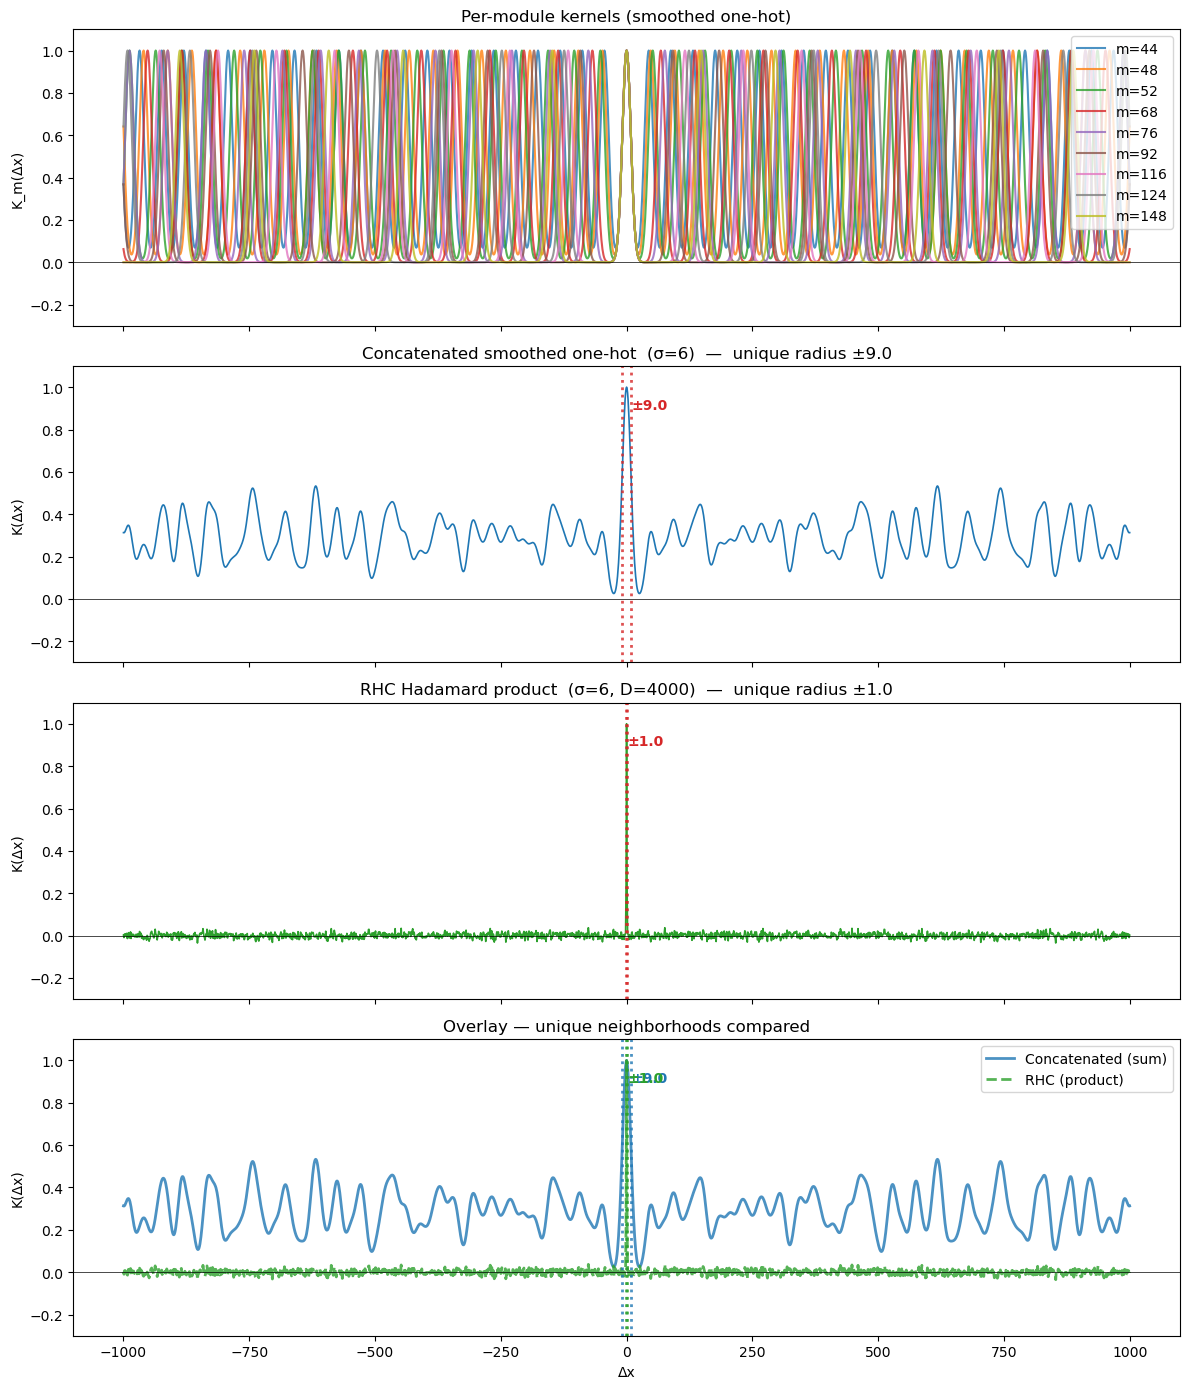


σ = 6, moduli = [ 44  48  52  68  76  92 116 124 148]
      Δx      Concat         RHC
----------------------------------
     0.0      1.0000      1.0000
     0.5      0.9983      0.6967
     1.0      0.9931      0.2362
     1.5      0.9845      0.0456
     2.0      0.9726      0.0089
     3.0      0.9394      0.0069
     5.0      0.8406     -0.0185
    10.0      0.4994      0.0138
    11.0      0.4316      0.0168
    12.0      0.3680     -0.0124
    13.0      0.3094      0.0002
    20.0      0.0647      0.0146


In [65]:
"""
Concatenated Smoothed One-Hot vs RHC — Real-Valued x
=====================================================
Both encodings handle real-valued x.
- Concat: Gaussian bump centered at fractional residue position
- RHC: fractional power encoding with Gaussian-weighted roots of unity
"""

import numpy as np
import matplotlib.pyplot as plt

# ---- Config ----
moduli = np.array([11, 12, 13, 17, 19, 23, 29, 31, 37]) * 4
sigma = 6  # gives good unique dropoff width
D = 4000
M = int(np.prod(moduli))
offset_max = min(M, 1000)
real_valued = False

# ============================================================
# Method 1: Concatenated smoothed one-hot (real-valued)
# ============================================================
def smooth_onehot(x, m, sigma):
    k = np.arange(m, dtype=float)
    center = x % m
    diff = k - center
    dist_k = np.abs(diff - m * np.round(diff / m))
    v = np.exp(-0.5 * (dist_k / sigma) ** 2)
    v /= np.linalg.norm(v)
    return v

def encode_concat(x):
    return np.concatenate([smooth_onehot(x, m, sigma) for m in moduli])

K0_concat = np.dot(encode_concat(0), encode_concat(0))

def kernel_concat(x1, x2):
    z1 = encode_concat(x1)
    z2 = encode_concat(x2)
    return np.dot(z1, z2) / K0_concat

# ============================================================
# Method 2: RHC with Gaussian-weighted roots of unity (real-valued)
# ============================================================
def make_weights(m, sigma):
    k = np.arange(m)
    dist_k = np.minimum(k, m - k).astype(float)
    w = np.exp(-0.5 * (dist_k / sigma) ** 2)
    w /= w.sum()
    return w

base_vectors = {}
for m in moduli:
    weights = make_weights(m, sigma)
    k = np.random.choice(m, size=D, p=weights)
    phi = 2 * np.pi * k / m
    base_vectors[m] = np.exp(1j * phi)

def encode_rhc(x):
    """z(x) = ⊙_k z_{m_k}^x — works for real x via fractional power."""
    vec = np.ones(D, dtype=complex)
    for m in moduli:
        vec *= base_vectors[m] ** x
    return vec

def kernel_rhc(x1, x2):
    z1 = encode_rhc(x1)
    z2 = encode_rhc(x2)
    return np.real(np.dot(z1.conj(), z2)) / D

# ============================================================
# Per-module kernels (analytic)
# ============================================================
def per_module_kernel(m, sigma, dx_array):
    v0 = smooth_onehot(0, m, sigma)
    return np.array([np.dot(v0, smooth_onehot(dx, m, sigma)) for dx in dx_array])

# ============================================================
# Evaluate — real-valued offsets
# ============================================================
if real_valued:
    offsets = np.linspace(-offset_max, offset_max, 801)
else:
    offsets = np.arange(-offset_max, offset_max + 1)

K_concat = np.array([kernel_concat(0, dx) for dx in offsets])
K_rhc    = np.array([kernel_rhc(0, dx) for dx in offsets])
K_per_mod = {m: per_module_kernel(m, sigma, offsets) for m in moduli}

# ============================================================
# Find unique neighborhood
# ============================================================
# Largest symmetric window [-r, r] around 0 such that
# min(K inside) > max(K outside).
# Equivalently: find where the kernel, moving outward from 0,
# first drops below the max of all values further out.

def find_unique_radius(offsets, K_vals):
    """
    Largest symmetric radius r such that every K value inside [-r, r]
    is strictly greater than every K value outside [-r, r].
    i.e., min(K in [-r,r]) > max(K outside [-r,r]).
    """
    center = len(offsets) // 2
    best_r = 0
    for i in range(1, center):
        r = offsets[center + i]
        inside = K_vals[center - i : center + i + 1]
        outside = np.concatenate([K_vals[:center - i], K_vals[center + i + 1:]])
        if len(outside) == 0:
            best_r = r
            continue
        if np.min(inside) > np.max(outside):
            best_r = r
        else:
            break
    return best_r

r_concat = find_unique_radius(offsets, K_concat)
r_rhc = find_unique_radius(offsets, K_rhc)

print(f"\nUnique neighborhood radius:")
print(f"  Concatenated: ±{r_concat:.2f}")
print(f"  RHC product:  ±{r_rhc:.2f}")

def add_unique_lines(ax, radius, color='red'):
    ax.axvline(-radius, color=color, ls=':', lw=2, alpha=0.8)
    ax.axvline(radius, color=color, ls=':', lw=2, alpha=0.8)
    ax.text(radius + 0.3, 0.95, f'±{radius:.1f}', color=color, fontsize=10,
            va='top', fontweight='bold')

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

# Per-module kernels
ax = axes[0]
for m in moduli:
    ax.plot(offsets, K_per_mod[m], label=f'm={m}', alpha=0.8)
ax.set_ylabel('K_m(Δx)')
ax.set_title('Per-module kernels (smoothed one-hot)')
ax.legend()
ax.set_ylim(-0.3, 1.1)

# Concatenated
ax = axes[1]
ax.plot(offsets, K_concat, 'C0-', lw=1.2)
add_unique_lines(ax, r_concat, 'C3')
ax.set_ylabel('K(Δx)')
ax.set_title(f'Concatenated smoothed one-hot  (σ={sigma})  —  unique radius ±{r_concat:.1f}')
ax.set_ylim(-0.3, 1.1)

# RHC
ax = axes[2]
ax.plot(offsets, K_rhc, 'C2-', lw=1.2)
add_unique_lines(ax, r_rhc, 'C3')
ax.set_ylabel('K(Δx)')
ax.set_title(f'RHC Hadamard product  (σ={sigma}, D={D})  —  unique radius ±{r_rhc:.1f}')
ax.set_ylim(-0.3, 1.1)

# Overlay
ax = axes[3]
ax.plot(offsets, K_concat, 'C0-', lw=2, alpha=0.8, label='Concatenated (sum)')
ax.plot(offsets, K_rhc, 'C2--', lw=2, alpha=0.8, label='RHC (product)')
add_unique_lines(ax, r_concat, 'C0')
add_unique_lines(ax, r_rhc, 'C2')
ax.set_ylabel('K(Δx)')
ax.set_xlabel('Δx')
ax.set_title('Overlay — unique neighborhoods compared')
ax.legend()
ax.set_ylim(-0.3, 1.1)

for ax in axes:
    ax.axhline(0, color='k', lw=0.5)

plt.tight_layout()
plt.savefig('concat_vs_rhc_real.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Print ----
print(f"\n{'='*60}")
print(f"σ = {sigma}, moduli = {moduli}")
print(f"{'='*60}")
print(f"{'Δx':>8}  {'Concat':>10}  {'RHC':>10}")
print(f"{'-'*34}")
for dx in [0, 0.5, 1, 1.5, 2, 3, 5, 10, 11, 12, 13, 20]:
    print(f"{dx:>8.1f}  {kernel_concat(0, dx):>10.4f}  {kernel_rhc(0, dx):>10.4f}")